# Tubes 1 IF3270 Pembelajaran Mesin

**Nama Anggota:**
- 13523137 — Muhammad Aulia Azka
- 13523147 — Frederiko Eldad Mugiyono
- 13523149 — Naufarrel Zhafif Abhista

**Kelas:** K3

---

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 0. Import Libraries & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from pathlib import Path

# Evaluation
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay


import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [4]:
csv_path = Path("..") / "data" / "global_student_placement_and_salary.csv"
df = pd.read_csv(csv_path)

df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [6]:
target_col = "placement_status"
stratify_col = df[target_col] if df[target_col].nunique() < 50 else None
train_set, val_set = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col
)

print(f"train_set: {train_set.shape}")
print(f"val_set: {val_set.shape}")

train_set: (8000, 12)
val_set: (2000, 12)


---
## 1. Exploratory Data Analysis (EDA)


### 1.1 Gambaran Umum Dataset

In [7]:
train_set.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
2014,7.663580,1,Tier 1,Germany,300+,0,89.685008,75.081917,Data Science,Consulting,6.405241,Placed
3522,6.227468,1,Tier 3,UK,Top 100,2,86.843058,47.547940,Data Science,Tech,3.410235,Placed
83,6.585384,0,Tier 2,USA,300+,1,56.855886,93.923403,Cloud,Consulting,7.129919,Placed
9038,7.619218,0,Tier 2,India,100-300,2,54.140379,46.012573,Cloud,Finance,6.924698,Placed
3984,7.194306,4,Tier 2,India,100-300,0,54.974271,61.241897,AI/ML,Healthcare,5.029638,Not Placed


In [8]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 2014 to 6802
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      8000 non-null   float64
 1   backlogs                  8000 non-null   int64  
 2   college_tier              8000 non-null   object 
 3   country                   8000 non-null   object 
 4   university_ranking_band   8000 non-null   object 
 5   internship_count          8000 non-null   int64  
 6   aptitude_score            8000 non-null   float64
 7   communication_score       8000 non-null   float64
 8   specialization            8000 non-null   object 
 9   industry                  8000 non-null   object 
 10  internship_quality_score  8000 non-null   float64
 11  placement_status          8000 non-null   object 
dtypes: float64(4), int64(2), object(6)
memory usage: 812.5+ KB


In [9]:
train_set.describe(include='all')

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
count,8000.000000,8000.000000,8000,8000,8000,8000.000000,8000.000000,8000.000000,8000,8000,8000.000000,8000
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,5,6,NaN,2
top,NaN,NaN,Tier 2,Germany,300+,NaN,NaN,NaN,Data Science,Consulting,NaN,Placed
freq,NaN,NaN,3181,1662,3241,NaN,NaN,NaN,1650,1391,NaN,4922
mean,7.000000,1.245750,NaN,NaN,NaN,1.490750,69.777144,65.254494,NaN,NaN,5.027980,NaN
std,0.799038,1.151422,NaN,NaN,NaN,1.196597,14.694668,14.806830,NaN,NaN,1.508694,NaN
min,4.000000,0.000000,NaN,NaN,NaN,0.000000,30.000000,30.000000,NaN,NaN,1.000000,NaN
25%,6.462682,0.000000,NaN,NaN,NaN,1.000000,59.768531,55.166849,NaN,NaN,4.019012,NaN
50%,6.999957,1.000000,NaN,NaN,NaN,1.000000,70.071892,65.102099,NaN,NaN,5.023714,NaN
75%,7.536212,2.000000,NaN,NaN,NaN,2.000000,80.109599,75.462671,NaN,NaN,6.034673,NaN


In [10]:
# Cek missing values
missing = train_set.isnull().sum()
missing_pct = (missing / len(train_set) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [12]:
# Distribusi kelas target
print(train_set['placement_status'].value_counts())
print(train_set['placement_status'].value_counts(normalize=True).round(3))

placement_status
Placed        4922
Not Placed    3078
Name: count, dtype: int64
placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64


In [14]:
train_set.value_counts("specialization")

specialization
Data Science     1650
Core CS          1617
Cloud            1584
Cybersecurity    1581
AI/ML            1568
Name: count, dtype: int64

In [15]:
train_set.value_counts("college_tier")

college_tier
Tier 2    3181
Tier 1    2446
Tier 3    2373
Name: count, dtype: int64

### 1.2 Distribusi Target dan Fitur Kategorikal Utama


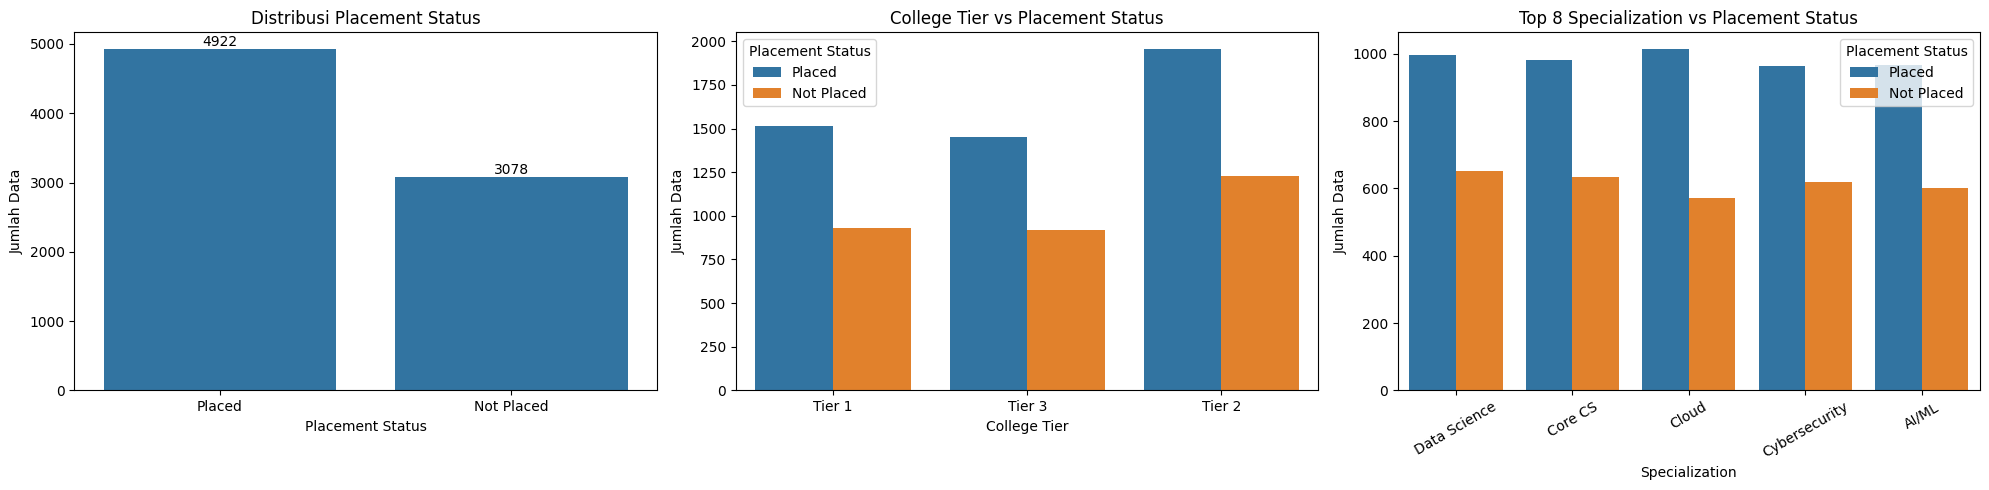

,proporsi
placement_status,
Placed,61.52
Not Placed,38.48


In [13]:
train_df = train_set.copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Distribusi target
target_order = train_df[target_col].value_counts().index
sns.countplot(data=train_df, x=target_col, order=target_order, ax=axes[0])
axes[0].set_title("Distribusi Placement Status")
axes[0].set_xlabel("Placement Status")
axes[0].set_ylabel("Jumlah Data")

for p in axes[0].patches:
    axes[0].annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=10
    )

sns.countplot(data=train_df, x="college_tier", hue=target_col, ax=axes[1])
axes[1].set_title("College Tier vs Placement Status")
axes[1].set_xlabel("College Tier")
axes[1].set_ylabel("Jumlah Data")
axes[1].legend(title="Placement Status")

# Top specialization vs target
top_spec = train_df["specialization"].value_counts().head(8).index
spec_df = train_df[train_df["specialization"].isin(top_spec)]

sns.countplot(
    data=spec_df,
    x="specialization",
    hue=target_col,
    order=top_spec,
    ax=axes[2]
)
axes[2].set_title("Top 8 Specialization vs Placement Status")
axes[2].set_xlabel("Specialization")
axes[2].set_ylabel("Jumlah Data")
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend(title="Placement Status")

plt.tight_layout()
plt.show()

# Tabel proporsi target
display(
    train_df[target_col]
    .value_counts(normalize=True)
    .rename("proporsi")
    .mul(100)
    .round(2)
    .to_frame()
)

### 1.3 Korelasi Antar Fitur Numerik


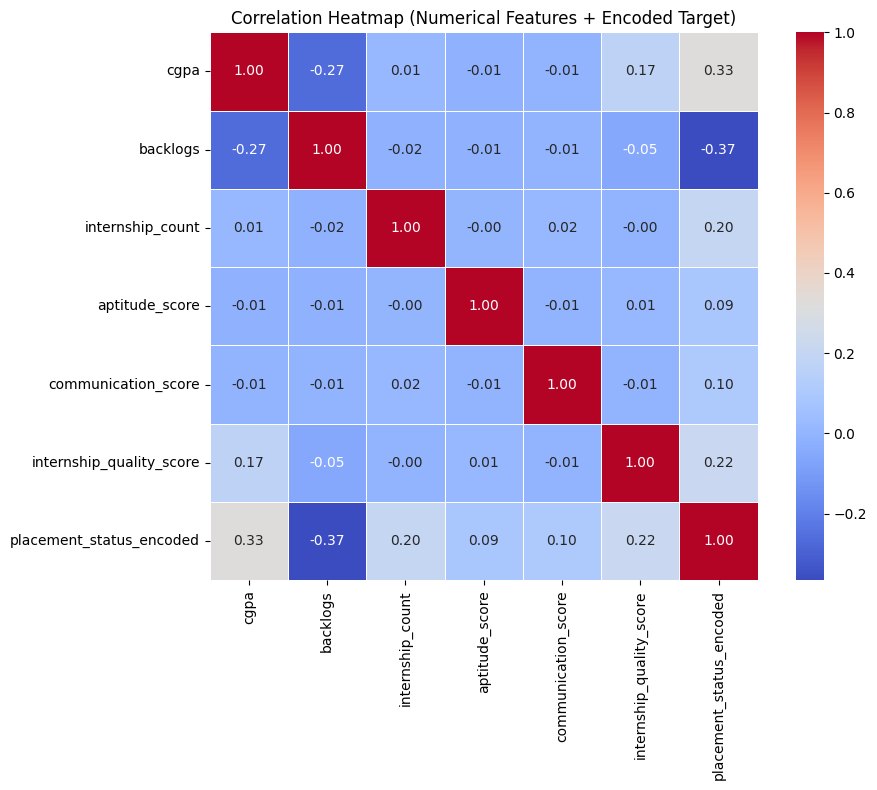

Mapping target untuk korelasi: {'Not Placed': 0, 'Placed': 1}


In [16]:
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

target_mapping = {label: idx for idx, label in enumerate(sorted(train_df[target_col].dropna().unique()))}
corr_df = train_df[num_cols].copy()
corr_df[f"{target_col}_encoded"] = train_df[target_col].map(target_mapping)

plt.figure(figsize=(10, 8))
corr_matrix = corr_df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap (Numerical Features + Encoded Target)")
plt.tight_layout()
plt.show()

print("Mapping target untuk korelasi:", target_mapping)

### 1.4 Sebaran Fitur Numerik dan Outlier terhadap Placement Status


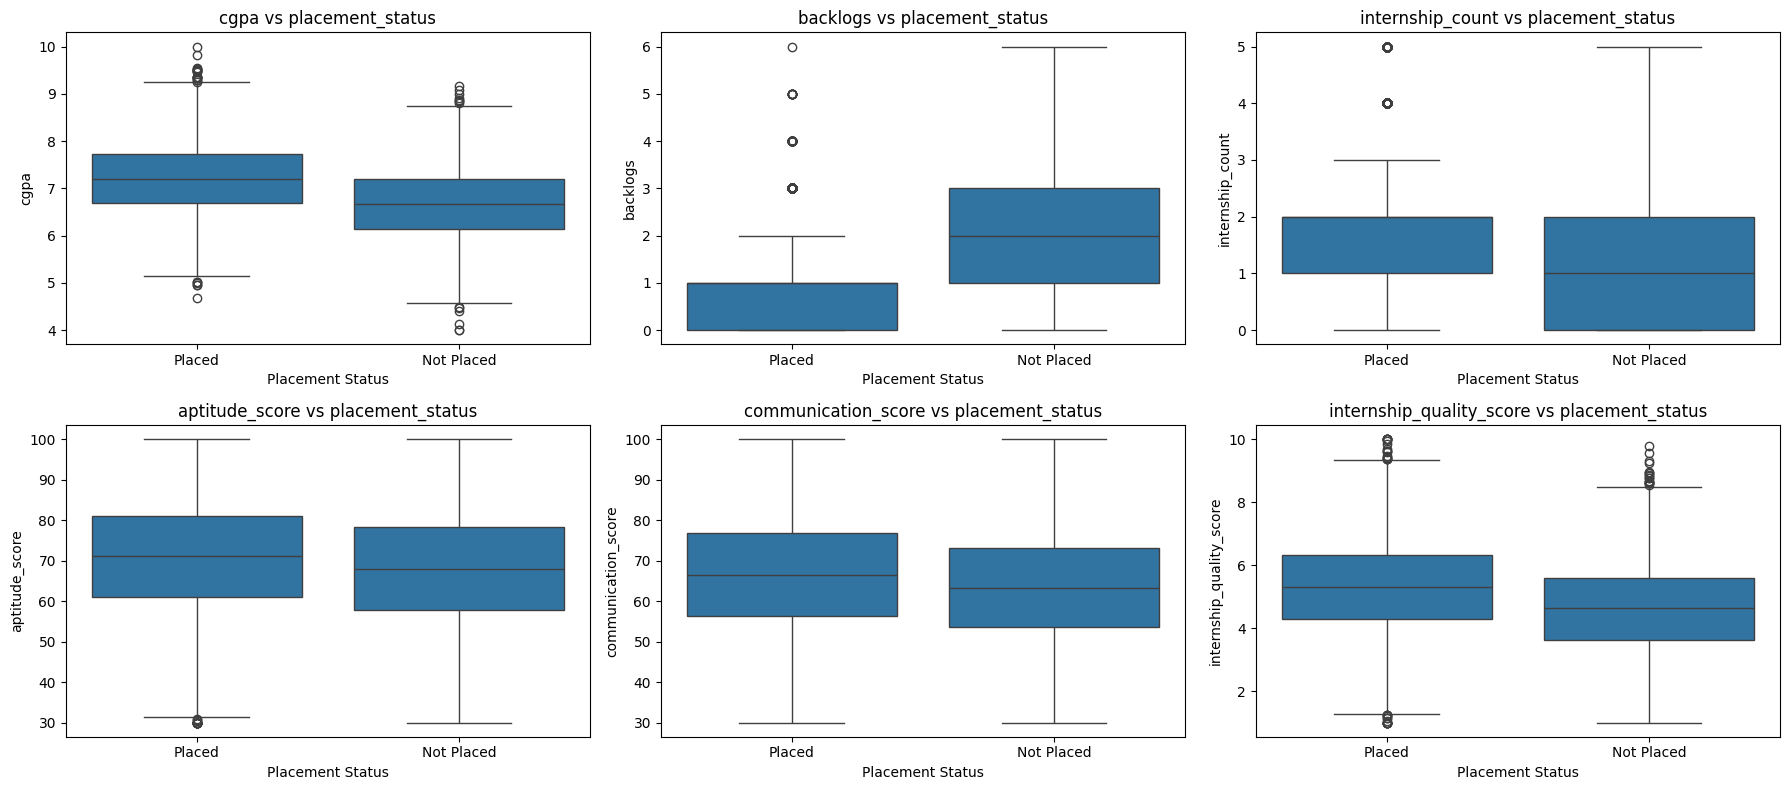

,feature,n_outlier,pct_outlier
2,internship_count,518,6.48
0,cgpa,59,0.74
5,internship_quality_score,31,0.39
1,backlogs,23,0.29
3,aptitude_score,0,0.00
4,communication_score,0,0.00


In [17]:
num_features = train_df.select_dtypes(include=[np.number]).columns.tolist()

n = len(num_features)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, num_features):
    sns.boxplot(data=train_df, x=target_col, y=col, ax=ax)
    ax.set_title(f"{col} vs {target_col}")
    ax.set_xlabel("Placement Status")
    ax.set_ylabel(col)

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Ringkasan outlier berbasis IQR
outlier_rows = []
for col in num_features:
    q1 = train_df[col].quantile(0.25)
    q3 = train_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    outlier_rows.append({
        "feature": col,
        "n_outlier": int(n_out),
        "pct_outlier": round(n_out / len(train_df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values("pct_outlier", ascending=False)
display(outlier_df)

---
## 2. Data Cleaning and Preprocessing


In [ ]:
TARGET_COL = 'label'
ID_COL     = 'device_id'
TS_COL = "timestamp"

CAT_COLS = ['device_type', 'is_encrypted']
NUM_COLS = [c for c in train_set.columns if c not in CAT_COLS + [TARGET_COL, ID_COL, TS_COL]]

print("Categorical:", CAT_COLS)
print("Numerical:  ", NUM_COLS)

# Buat salinan
train = train_set.copy()
test  = val_set.copy()

Categorical: ['device_type', 'is_encrypted']
Numerical:   ['cpu_usage', 'memory_usage', 'network_in_kb', 'network_out_kb', 'packet_rate', 'avg_response_time_ms', 'service_access_count', 'failed_auth_attempts', 'geo_location_variation']


### 2.1 Feature Engineering

### 2.2 Preprocessing


In [ ]:
class IQRClipper(BaseEstimator, TransformerMixin):
  def __init__(self, factor=1.5):
    self.factor = factor

  def fit(self, X, y=None):
    X = np.asarray(X, dtype=float)
    q1 = np.nanquantile(X, 0.25, axis=0)
    q3 = np.nanquantile(X, 0.75, axis=0)
    IQR = q3 - q1
    self.lower_ = q1 - IQR * self.factor
    self.upper_ = q3 + IQR * self.factor
    return self

  def transform(self, X):
    X = np.asarray(X, dtype=float)
    return np.clip(X, self.lower_, self.upper_)

# OneHotEncoder
try:
  onehoten = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except:
  onehoten = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", IQRClipper()),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehoten)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUM_COLS),
        ("cat", categorical_transformer, CAT_COLS)
    ],
    remainder="drop"
)


### 2.6 Train-Validation Split

In [ ]:
feature_cols = [c for c in train.columns if c not in [TARGET_COL, ID_COL, TS_COL]]

X            = train[feature_cols]
y            = train[TARGET_COL]
X_test_final = test[feature_cols]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)

X_train: (6400, 11) | y_train: (6400,)
X_val:   (1600, 11) | y_val:   (1600,)


---
## 3. Baseline Config


In [ ]:
# Helper: evaluasi model dan simpan hasil
results = {}

def evaluate_model(model, X_val, y_val, model_name="Model"):
    y_pred = model.predict(X_val)
    print(f"{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_val, y_pred))
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    print(f">>> Macro F1-Score: {macro_f1:.4f}\n")
    return macro_f1

In [ ]:
# Pipeline
def make_pipe(model):
  return Pipeline(steps=[
      ("preprocessor", preprocessor),
      ("model", model)
  ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def tune_model(pipe, param_grid=None, param_distributions=None, n_iter=5, scoring="f1_macro"):
  if param_distributions is not None:
    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )
  else:
    search = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

  search.fit(X_train, y_train)
  return search

trained_models = {}
results = {}

# 4. Eksperimen

## 4.1 Variasi Depth dan Width

### 4.1.1 A

In [ ]:
# TODO: Variasi 1

### 4.1.2 B

In [ ]:
# TODO: Variasi 2

### 4.1.3 C

In [ ]:
# TODO: Variasi 3

## 4.2 Variasi Fungsi Aktivasi 

### 4.2.1 A

In [ ]:
# TODO: Variasi Base Arsitektur 1

### 4.2.2 B

In [ ]:
# TODO: Variasi Base Arsitektur 2

### 4.2.3 C

In [ ]:
# TODO: Variasi Base Arsitektur 3

## 4.3 Variasi Learning Rate

### 4.3.1 A

In [ ]:
# TODO: Variasi Learning Rate 1

### 4.3.2 B

In [ ]:
# TODO: Variasi Learning Rate 2

### 4.3.3 C

In [ ]:
# TODO: Variasi Learning Rate 3

## 4.4 Pengaruh Regularisasi

### 4.4.1 A

In [ ]:
# TODO: Tanpa Regularisasi

### 4.4.2 B

In [ ]:
# TODO: Regularisasi L1

### 4.4.3 C

In [ ]:
# TODO: Regularisasi L2

## 4.5 Uji Perbandingan

### 4.5.1 SKLearn

In [ ]:
# TODO: Implementasi SKlearn

### 4.5.2 Scratch

In [ ]:
# TODO: Implementasi Scratch